In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import warnings

from src.utils.utils import find_project_root

BASE_DIR = find_project_root()

EXTERNAL_DATA_DIR = BASE_DIR / "data" / "external"
DATA_DIR = BASE_DIR / "data" / "processed" / "fig5_data"
MODEL_DIR = BASE_DIR / "models" 

from figures.fig_scripts.fig5_data_processing import *
from figures.fig_scripts.fig5_plotting import *

In [3]:
# Suppress AnnData UserWarnings
warnings.filterwarnings("ignore", category=UserWarning, module="anndata")

#### Import data from spatial reconstruction paper: zenodo.org/records/3403670

In [4]:
umi_data_b = pd.read_csv(EXTERNAL_DATA_DIR / "table_B_scRNAseq_UMI_counts.tsv", sep="\t")

#### Import data generated from MATLAB script: src/analyhsis/compute_spatial_coordinates_zones_and_crypt.m

In [5]:
# Landmark genes from the paper:
lm_genes = pd.read_csv(EXTERNAL_DATA_DIR / "landmark_genes.txt", sep="\t", header=None)
lm_genes_upper = lm_genes[0].str.upper().tolist()

# Cutoff values for zone assignment:
zone_cutoff_df = pd.read_csv(EXTERNAL_DATA_DIR / "zone_cutoff_values.csv", index_col=0)

#### Cell zone table generated in src/preprocessing/process_spatial_data.py

In [6]:
cell_zone_table_with_crypt = pd.read_csv(
    EXTERNAL_DATA_DIR / "cell_zone_table_with_crypt.txt", sep="\t"
)

#### Load training, testing and sptial datasets:

In [7]:
# load split data:
X_train = pd.read_pickle(DATA_DIR / "X_train_2250.pkl")
X_test = pd.read_pickle(DATA_DIR / "X_test_2250.pkl")
y_train = np.load(DATA_DIR / "y_train_2250.npy")
y_test = np.load(DATA_DIR / "y_test_2250.npy")
adata_final = sc.read_h5ad(DATA_DIR / "adata_final_2250.h5ad")
df_final = pd.read_pickle(DATA_DIR / "df_final_2250.pkl")

# load spatial data:
adata_spatial = sc.read_h5ad(DATA_DIR / "adata_spatial_2250.h5ad")
df_spatial = pd.read_pickle(DATA_DIR / "df_spatial_2250.pkl")

In [8]:
model_path = MODEL_DIR / "xgboost_min_cells_20_2250_group_200_20260212" / "xgboost_min_cells_20_2250.json"
model_xgb = xgb.Booster()
model_xgb.load_model(model_path)

#### Generate training objects:

In [9]:
train_obj = PipelineData(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    adata_final=adata_final,
    df_final=df_final,
    adata_spatial=adata_spatial,
    df_spatial=df_spatial,
    dtrain=xgb.DMatrix(X_train, label=y_train),
    dtest=xgb.DMatrix(X_test, label=y_test),
    dspatial=xgb.DMatrix(df_spatial),
    cutoffs_df=zone_cutoff_df,
)

In [10]:
pred_obj = generate_conc_predictions_df(train_obj, model_xgb, copy=True)

### Panel A: Cumulative ROC plot

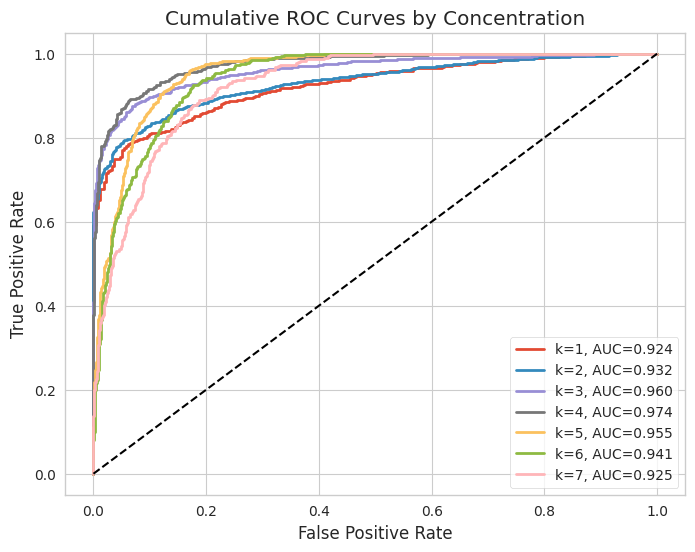

In [11]:
plot_cumulative_roc(pred_obj, save=False)

### Panel B: Aggregated Predicted Probabilities Heatmap

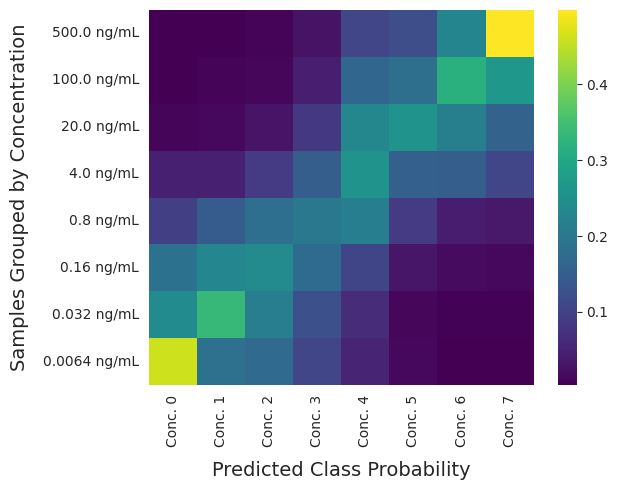

In [12]:
plot_agg_probabilities(pred_obj, save=False)

#### Fitting predicted concentratiosns to Gaussian:

In [40]:
pred_obj_pc = generate_conc_reconstruction_df(
    pred_obj, source="test", reg_strength=0.075, copy=True
)

Estimated global sigma: 1.2305
Reconstruction dataframe shape change (test):
  Shape before: (2098, 11)
  Shape after : (2098, 13)


### Panel C: Concentration Prediction   

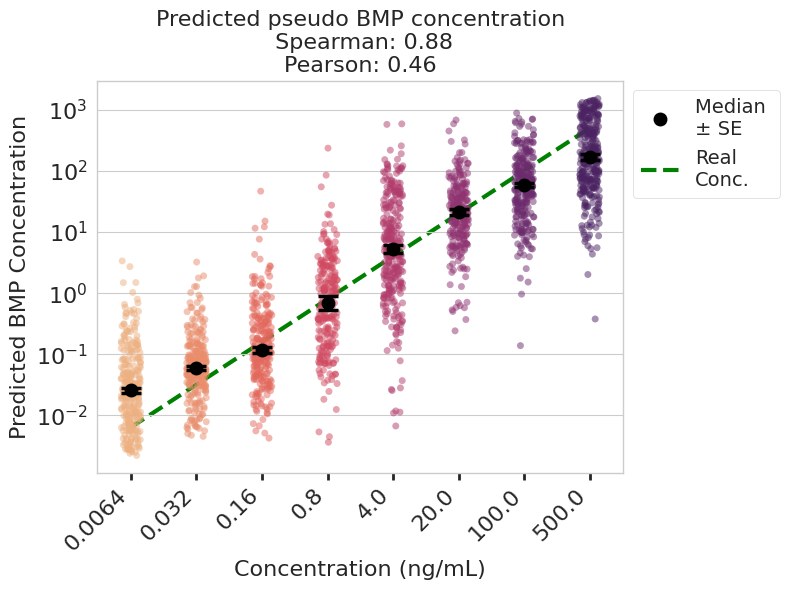

In [41]:
plot_conc_prediction(
    pred_obj_pc, CONCENTRATIONS, reconstruction=True, save=False
)

#### Save predictions daraframe:

In [55]:
preds_df = pred_obj_pc.xgb_pred_df
preds_df.to_pickle(DATA_DIR / "xgb_pred_df_2250.pkl")

#### Create prediction spatial object

In [42]:
spatial_obj = process_spatial_data(
    pred_obj, model_xgb, binned_col="continuous_zone", copy=True, normalized=True
)

Spatial prediction split summary:
  Crypt cells   : 235
  Non-crypt cells: 1148
  Matrix after zone split: (1383, 14)
  Binned non-crypt matrix shape: (1148, 15)


#### Fitting sptial predicted concentratiosns to Gaussian:

In [43]:
spatial_obj_pc = generate_conc_reconstruction_df(
    spatial_obj,
    binned_col="norm_continuous_zone",
    source="spatial",
    reg_strength=0.075,
    copy=True
)

Estimated global sigma: 1.5312
Reconstruction dataframe shape change (spatial):
  Shape before: (1383, 14)
  Shape after : (1383, 16)


In [44]:
get_exponential_fit_params(spatial_obj_pc)

Fitted exponential decay constant k: 4.6007
Estimated concentration at source : 9.9531
Estimated half-distance: 0.1507
R-squared of fit: 0.9503


#### Run diffusion analysis:

In [45]:
#print results round to 3 decimal places:
results = spatial_obj_pc.decay_results
decay_constant = results['params'][0]
c_source = results["c_source"]
c_source_ci_lower = results["c_source_ci"][0]
c_source_ci_upper = results["c_source_ci"][1]
half_distance = results["half_distance"]
r2 = results["r2"]

print(f"Decay constant: {decay_constant:.3f}")
print(f"Source concentration: {c_source:.3f} (95% CI: [{c_source_ci_lower:.3f}, {c_source_ci_upper:.3f}])")
print(f"Half-distance: {half_distance:.3f}")
print(f"R-squared: {r2:.3f}")  


Decay constant: 4.601
Source concentration: 9.953 (95% CI: [7.347, 13.483])
Half-distance: 0.151
R-squared: 0.950


### Panel D: Villi Spatial Concentration Prediction

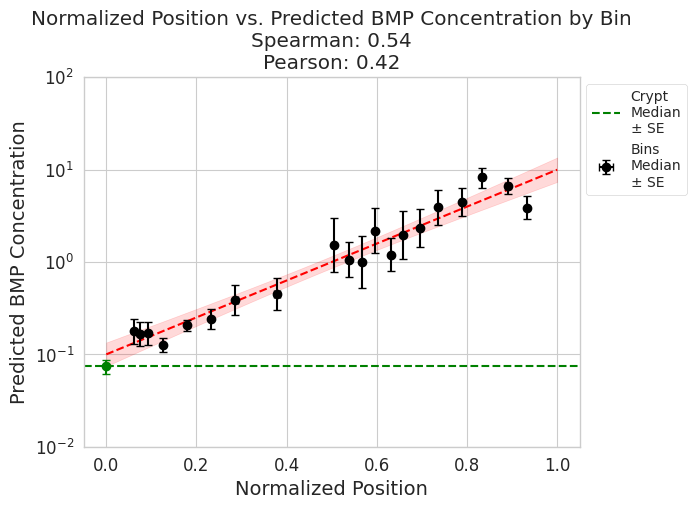

In [46]:
plot_spatial_predicted_conc(
    spatial_obj_pc,
    binned_col="norm_continuous_zone",
    hue="bins",
    plot_fit=True,
    save=False,
    only_bins=True,
    ylim=(1e-2, 1e2)
)

## Supplementary Figure:

### Supplementary Panel A: Train vs Test Distribution

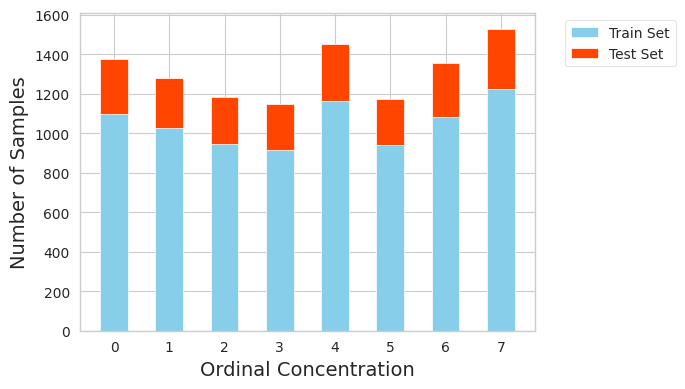

In [47]:
plot_train_test_distribution(pred_obj)

### Supplementary Panel B: Single Cell Predicted Probabilities Heatmap

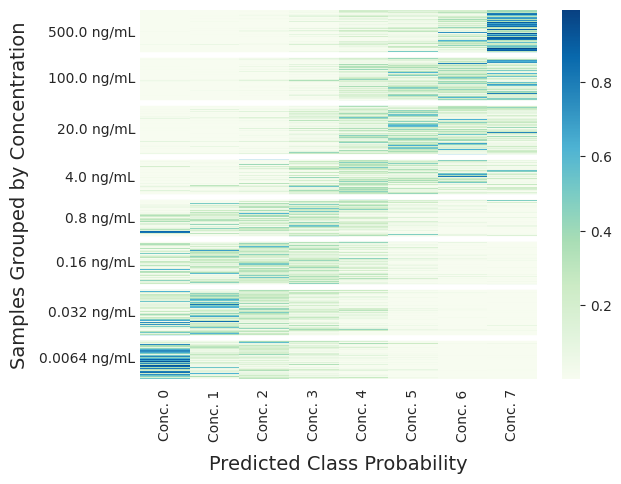

In [48]:
plot_sc_probabilities(pred_obj, save=False)

### Supplementary Panel C: Test set confusion matrix

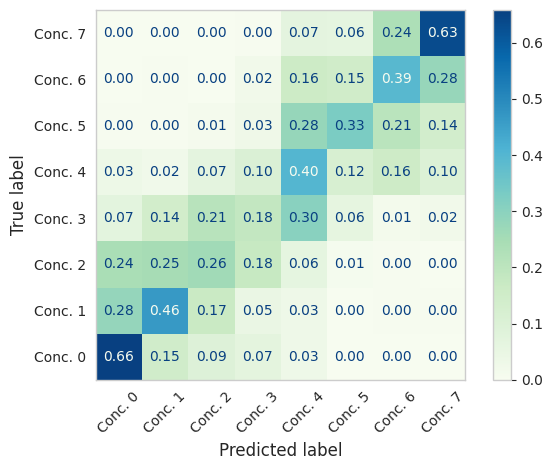

In [49]:
plot_confusion_matrix(pred_obj, save=False)

### Supplementary Panel D: Variance of Scores by Concentration

To match the cells of the test set we need to regenrate the PCA results with barcodes attached

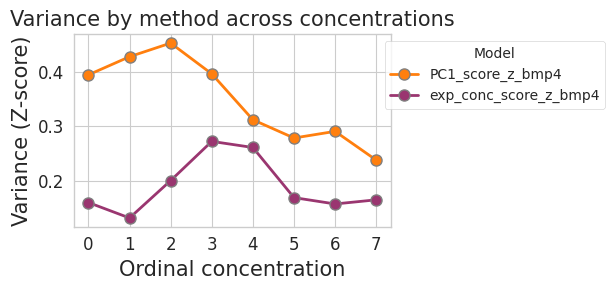

In [56]:
from figures.fig_scripts.fig5_supplementary_panel_d import run_panel_d_variance_analysis
# check if DATA_DIR / "xgb_pred_df_2250.pkl" exist:



panel_d_results = run_panel_d_variance_analysis(DATA_DIR, save=True)
vars_for_plot = panel_d_results["vars_for_plot"]
